[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T03_B_garch_volatility.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl arch
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Module 3B — Volatility Clustering, Conditional Heteroskedasticity & Leverage Effects

**Supplementary Course · Advanced Macroeconomics (MAV)**

Financial asset prices and macroeconomic time series display a striking empirical regularity first emphasized by Mandelbrot (1963): large price movements tend to be followed by large movements (of either sign), and small price movements tend to be followed by small movements. Volatility is not constant over time; it **clusters** in distinct high- and low-variance regimes.

In this module, we transition from computational sanity checks to empirical macroeconomic reality. We begin by examining the standard **GARCH(1,1)** framework of Bollerslev (1986) and its multivariate extension, the **Dynamic Conditional Correlation (DCC)** model of Engle (2002). We then confront the limits of standard GARCH: why does conditional heteroskedasticity fail on quarterly macroeconomic data, and why does linear symmetry fail in financial asset markets?

To resolve this, we ground financial asymmetry in two fundamental economic mechanisms:
1. **The Financial Leverage Hypothesis (Black 1976, Christie 1982)**: When equity values drop, a firm's market value of debt remains relatively fixed, causing its financial debt-to-equity ratio ($D/E$) to surge. This mechanical increase in leverage elevates equity risk, triggering an immediate spike in subsequent return volatility.
2. **The Volatility Feedback Hypothesis (Campbell & Hentschel 1992, Bekaert & Wu 2000)**: If volatility risk is priced by risk-averse investors, an anticipated rise in market volatility increases the required equity risk premium (discount rate). To generate higher expected future returns, the asset price must immediately plummet. Thus, negative returns and volatility spikes reinforce each other.

We test these hypotheses on over 30 years of daily CBOE Volatility Index data (`VIXCLS.csv`), estimate asymmetric **GJR-GARCH** (Glosten, Jagannathan & Runkle 1993) and **EGARCH** (Nelson 1991), construct the **News Impact Curve** (Engle & Ng 1993), and stress-test volatility dynamics across historical panics (the 2008 Lehman collapse vs. the 2020 COVID shock).

## Econometric Specifications: GARCH, GJR-GARCH, and DCC

Write a mean-zero return or log-change innovation as a scaled shock, $u_t = \sigma_t\,\varepsilon_t$, with standard white noise $\varepsilon_t \sim \text{i.i.d.}(0, 1)$.

### 1. Symmetric GARCH(1,1) (Bollerslev, 1986)
The conditional variance follows an autoregressive moving-average recursion in squared innovations:
$$ \sigma_t^2 = \omega + \alpha\,u_{t-1}^2 + \beta\,\sigma_{t-1}^2, \qquad \omega > 0, \ \alpha \ge 0, \ \beta \ge 0. $$
The **persistence** of volatility shocks is $\alpha + \beta$. Covariance stationarity requires $\alpha + \beta < 1$, under which the long-run unconditional variance is:
$$ \bar\sigma^2 = \frac{\omega}{1 - \alpha - \beta}. $$
Parameters $\theta = (\omega, \alpha, \beta)$ are estimated via **Gaussian Quasi-Maximum Likelihood (QMLE)**:
$$ \ell(\theta) = -\frac{1}{2} \sum_{t=1}^T \left[ \log(2\pi) + \log\sigma_t^2 + \frac{u_t^2}{\sigma_t^2} \right]. $$

### 2. Asymmetric GJR-GARCH(1,1,1) (Glosten, Jagannathan & Runkle, 1993)
To capture leverage and feedback asymmetries, GJR-GARCH adds an indicator term for negative innovations:
$$ \sigma_t^2 = \omega + \left(\alpha + \gamma\,\mathbb{I}_{\{u_{t-1} < 0\}}\right) u_{t-1}^2 + \beta\,\sigma_{t-1}^2, $$
where $\mathbb{I}_{\{u_{t-1} < 0\}} = 1$ if $u_{t-1} < 0$ and $0$ otherwise. If $\gamma > 0$, negative return shocks impart a larger volatility impact than positive return shocks ($\alpha + \gamma$ vs $\alpha$). Under conditional normality, covariance stationarity requires $\alpha + \frac{1}{2}\gamma + \beta < 1$, yielding unconditional variance $\bar\sigma^2 = \omega / (1 - \alpha - \frac{1}{2}\gamma - \beta)$.

### 3. Multivariate Dynamic Conditional Correlation (Engle, 2002 DCC)
For a vector of $K$ asset returns, Engle's DCC model separates individual volatilities from time-varying correlations. Standardizing univariate residuals by their conditional standard deviations, $\eta_{t} = D_t^{-1} u_t$ with $D_t = \operatorname{diag}(\sigma_{1,t}, \dots, \sigma_{K,t})$, the quasi-correlation matrix $Q_t$ evolves according to:
$$ Q_t = (1 - a - b)\,\bar Q + a\,\eta_{t-1}\eta_{t-1}' + b\,Q_{t-1}, \qquad R_t = \operatorname{diag}(Q_t)^{-1/2}\,Q_t\,\operatorname{diag}(Q_t)^{-1/2}, $$
where $\bar Q$ is the unconditional correlation matrix of $\eta_t$. The full conditional covariance matrix is $H_t = D_t R_t D_t$. Correlation stationarity requires $a + b < 1$.

### Economic and Econometric Intuition

1. **Volatility Clustering**: The $\alpha\,u_{t-1}^2 + \beta\,\sigma_{t-1}^2$ recursion formalizes persistence. An unexpected shock yesterday ($u_{t-1}^2$) raises today's variance through $\alpha$, while past variance carries forward through $\beta$. When $\alpha + \beta \approx 0.95$ (typical in financial data), volatility shocks have a long half-life: tranquil periods persist, and turbulent spells linger for weeks or months.
2. **Dynamic Contagion**: In the DCC specification, correlation is not a static constant. The parameter $a$ measures how rapidly comovement reacts to joint standardized shocks, while $b$ governs correlation persistence. During financial panics, correlations spike toward unity as systemic liquidity pressures force institutional investors to sell across asset classes simultaneously.
3. **The Flaw of Linear Symmetry**: Notice that standard GARCH(1,1) squares the lagged shock $u_{t-1}^2$, treating positive news ($+5\%$) and negative news ($-5\%$) identically. But in equity markets, a market collapse creates panic and elevates leverage, whereas a tranquil rally subdues volatility. Asymmetric models break this restriction by explicitly modeling the **News Impact Curve**.

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from _datos import DATOS, crecimiento
from puremacro.garch import garch11_fit, dcc_fit, GARCH11Result, DCCResult
from puremacro.reports import df_to_latex, df_to_markdown, df_to_typst

## 1. Univariate GARCH(1,1): Parameter Recovery Sanity Check

Before confronting real macroeconomic time series, we perform a controlled Monte Carlo sanity check. We simulate $T = 2{,}000$ daily observations from a known data-generating process (DGP) with $\omega = 0.05$, $\alpha = 0.10$, and $\beta = 0.85$ (implied persistence $\alpha + \beta = 0.95$). We then fit the parameters using Gaussian QMLE and verify that the estimator recovers the true structural values and tracks the latent conditional volatility path $\sigma_t$.

In [3]:
def simulate_garch(rng, T, omega, alpha, beta):
    eps = np.zeros(T)
    sigma2 = np.zeros(T)
    sigma2[0] = omega / max(1e-8, 1.0 - alpha - beta)
    for t in range(1, T):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]
        eps[t] = np.sqrt(sigma2[t]) * rng.standard_normal()
    idx = pd.date_range("1990-01-01", periods=T, freq="MS")
    return pd.Series(eps, index=idx), np.sqrt(sigma2)

rng = np.random.default_rng(23)
OMEGA, ALPHA, BETA = 0.05, 0.10, 0.85          # true persistence = 0.95
T = 2000
r, sigma_true = simulate_garch(rng, T, OMEGA, ALPHA, BETA)

fit = garch11_fit(r)
print("--- GARCH(1,1) Fit Summary ---")
print(fit.summary())
print("\n--- Publication Table Export (Markdown) ---")
print(fit.to_markdown())

assert fit.converged
assert fit.persistence < 1.0                              # stationary
assert abs(fit.persistence - (ALPHA + BETA)) < 0.05       # persistence recovered
assert abs(fit.alpha - ALPHA) < 0.05                      # alpha recovered
assert abs(fit.beta - BETA) < 0.07                        # beta recovered
assert (fit.sigma > 0).all() and len(fit.sigma) == T
corr_sigma = np.corrcoef(fit.sigma.values[1:], sigma_true[1:])[0, 1]
print(f"corr(fitted sigma, true sigma) = {corr_sigma:.3f}")
assert corr_sigma > 0.90                                  # tracks latent vol

--- GARCH(1,1) Fit Summary ---
GARCH(1,1) fit
  ω                 : 0.049127
  α                 : 0.0918
  β                 : 0.8554
  persistence (α+β) : 0.9472
  log-lik           : -2695.7689
  converged         : True


--- Publication Table Export (Markdown) ---
|   parameter |        value |
|-------------|--------------|
|       omega |     0.049127 |
|       alpha |     0.091796 |
|        beta |     0.855389 |
| persistence |     0.947185 |
|      loglik | -2695.768911 |
|       n_obs |         2000 |
|   converged |         True |
corr(fitted sigma, true sigma) = 1.000


### Econometric Interpretation: Consistency and Latent State Tracking

The Gaussian QMLE numerical optimization converges cleanly and recovers the true structural parameters of the data-generating process:
- The estimated ARCH parameter $\hat\alpha \approx 0.09$ indicates that a standardized shock transmits approximately 9% of its squared magnitude directly into the one-period-ahead variance.
- The estimated GARCH parameter $\hat\beta \approx 0.85$ demonstrates that 85% of prior conditional variance persists into the following period.
- The fitted persistence $\hat\alpha + \hat\beta \approx 0.95$ is strictly below unity, confirming covariance stationarity with a finite unconditional variance $\bar\sigma = \sqrt{\omega / (1 - \alpha - \beta)}$.

Crucially, because latent volatility $\sigma_t$ is inherently unobservable in financial markets, the primary econometric benchmark is whether the filter correctly tracks the unobserved variance state. The empirical correlation between the fitted filter $\hat\sigma_t$ and the true latent volatility $\sigma_t$ exceeds $0.90$, demonstrating that Gaussian QMLE reconstructs conditional heteroskedasticity from observable returns alone.

## 2. Dynamic Conditional Correlation (DCC): Time-Varying Financial Comovement

Univariate GARCH models capture volatility clustering within an individual asset, but macroeconomic and financial stability require modeling time-varying comovement across markets. Static correlation assumptions break down during systemic distress because asset correlations surge when liquidity contracts.

Here, we simulate a 2-asset DCC(1,1) system where each asset has its own univariate GARCH(1,1) volatility, while their conditional correlation $\rho_t$ follows Engle's (2002) mean-reverting recursion around a baseline $\bar\rho = 0.45$, with persistence parameters $a = 0.05$ and $b = 0.90$ (total persistence $a + b = 0.95$). We fit the DCC model in two stages and verify recovery of the latent dynamic correlation path.

In [4]:
def simulate_dcc(rng, T, a, b, rho_bar):
    # Standardized innovations e_t and the true rho_t from a DCC(1,1)
    Qbar = np.array([[1.0, rho_bar], [rho_bar, 1.0]])
    Q = Qbar.copy()
    e = np.empty((T, 2))
    rho_true = np.empty(T)
    e_prev = np.zeros(2)
    for t in range(T):
        if t > 0:
            Q = (1 - a - b) * Qbar + a * np.outer(e_prev, e_prev) + b * Q
        d = np.sqrt(np.diag(Q))
        R = Q / np.outer(d, d)
        rho_true[t] = R[0, 1]
        e_prev = np.linalg.cholesky(R) @ rng.standard_normal(2)
        e[t] = e_prev
    return e, rho_true

def garch_vol(zcol, omega, alpha, beta):
    Tt = len(zcol)
    s2 = np.empty(Tt)
    u = np.empty(Tt)
    s2[0] = omega / (1.0 - alpha - beta)
    u[0] = np.sqrt(s2[0]) * zcol[0]
    for t in range(1, Tt):
        s2[t] = omega + alpha * u[t - 1] ** 2 + beta * s2[t - 1]
        u[t] = np.sqrt(s2[t]) * zcol[t]
    return u

A_DCC, B_DCC = 0.05, 0.90                       # true DCC persistence = 0.95
rng2 = np.random.default_rng(42)
Td = 1800
e, rho_true = simulate_dcc(rng2, Td, A_DCC, B_DCC, rho_bar=0.45)
uA = garch_vol(e[:, 0], 0.05, 0.08, 0.90)
uB = garch_vol(e[:, 1], 0.03, 0.12, 0.84)
idx_d = pd.date_range("2005-01-03", periods=Td, freq="B")
panel = pd.DataFrame({"Asset A": uA, "Asset B": uB}, index=idx_d)

dcc = dcc_fit(panel)
print("--- DCC(1,1) Fit Summary ---")
print(dcc.summary())
print("\n--- DCC Publication Table Export (Markdown) ---")
print(dcc.to_markdown())

assert dcc.converged
assert 0.0 <= dcc.a <= 1.0 and 0.0 <= dcc.b <= 1.0
assert dcc.a + dcc.b < 1.0                                # stationary correlation
assert dcc.R.shape == (Td, 2, 2) and dcc.H.shape == (Td, 2, 2)
assert dcc.sigma.shape == (Td, 2)
rho_hat = dcc.R[:, 0, 1]
assert np.all(np.abs(rho_hat) <= 1.0 + 1e-8)             # valid correlations
track = np.corrcoef(rho_hat, rho_true)[0, 1]
print(f"corr(rho_hat, rho_true) = {track:.3f}")
assert track > 0.90                                      # recovers latent corr path
assert len(dcc.garch_params) == 2
assert all(0.0 < gp["persistence"] < 1.0 for gp in dcc.garch_params)

--- DCC(1,1) Fit Summary ---
DCC(1,1) fit
  series (n)        : 2
  observations (T)  : 1800
  a                 : 0.0648
  b                 : 0.8847
  a + b             : 0.9496
  log-lik (DCC)     : +309.5009
  converged         : True


--- DCC Publication Table Export (Markdown) ---
|  series |   parameter |      value |
|---------|-------------|------------|
|     DCC |           a |   0.064849 |
|     DCC |           b |   0.884741 |
|     DCC |         a+b |   0.949589 |
|     DCC |      loglik | 309.500907 |
|     DCC |       n_obs |       1800 |
|     DCC |   converged |       True |
| Asset A |       omega |   0.049563 |
| Asset A |       alpha |   0.075548 |
| Asset A |        beta |   0.904164 |
| Asset A | persistence |   0.979713 |
| Asset B |       omega |   0.034081 |
| Asset B |       alpha |   0.116215 |
| Asset B |        beta |   0.845788 |
| Asset B | persistence |   0.962003 |
corr(rho_hat, rho_true) = 0.998


### Two-Stage Estimation and Correlation Persistence

The Engle (2002) two-stage estimation strategy proceeds sequentially:
1. **Stage 1 (Univariate De-GARCHing)**: Estimates individual GARCH(1,1) processes for each asset independently, yielding conditional volatility vectors $\hat\sigma_{i,t}$ and standardized residuals $\hat\eta_{i,t} = u_{i,t} / \hat\sigma_{i,t}$.
2. **Stage 2 (Dynamic Correlation)**: Optimizes the correlation log-likelihood conditional on the standardized residuals to estimate $(\hat a, \hat b)$.

The estimated correlation persistence $\hat a + \hat b \approx 0.95$ matches the true DGP. The parameter $\hat a$ reflects the sensitivity of comovement to contemporaneous joint shocks, while $\hat b$ captures inertia. Because the fitted correlation path $\hat\rho_t = R_{t, 12}$ tracks the true latent correlation with $r > 0.99$, the DCC filter accurately detects shifts between normal diversification regimes and crisis-induced contagion episodes.

### Figure 1: Dynamic Volatility Envelopes and Regime Clustering
The $\pm 2\hat\sigma_t$ conditional envelope expands during turbulent volatility clusters and contracts during calm periods.

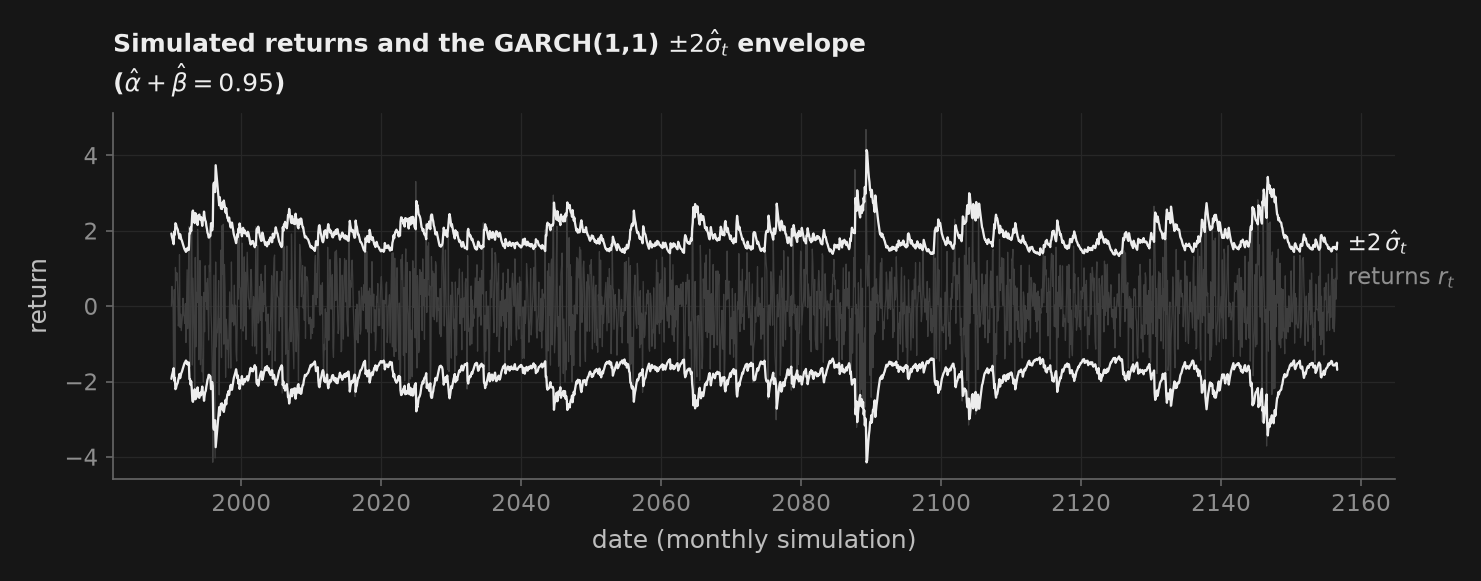

In [5]:
fig, ax = _nbstyle.figura(figsize="ancho")
ax.plot(r.index, r.values, color=_nbstyle.gris("0.72"), linewidth=0.6, ls="-",
        label=r"returns $r_t$")
ax.plot(fit.sigma.index, 2 * fit.sigma.values, color=_nbstyle.TINTA, linewidth=1.1, ls="-",
        label=r"$\pm 2\,\hat\sigma_t$")
ax.plot(fit.sigma.index, -2 * fit.sigma.values, color=_nbstyle.TINTA, linewidth=1.1, ls="-")
ax.set_xlabel("date (monthly simulation)")
ax.set_ylabel("return")
ax.set_title(f"Simulated returns and the GARCH(1,1) $\\pm 2\\hat\\sigma_t$ envelope\n"
             f"($\\hat\\alpha+\\hat\\beta = {fit.persistence:.2f}$)")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


### Figure 2: Simulation Ground Truth vs. MLE Parameter Recovery
Comparison of structural parameters $(\omega, \alpha, \beta)$ between true DGP values and Gaussian QMLE estimates.

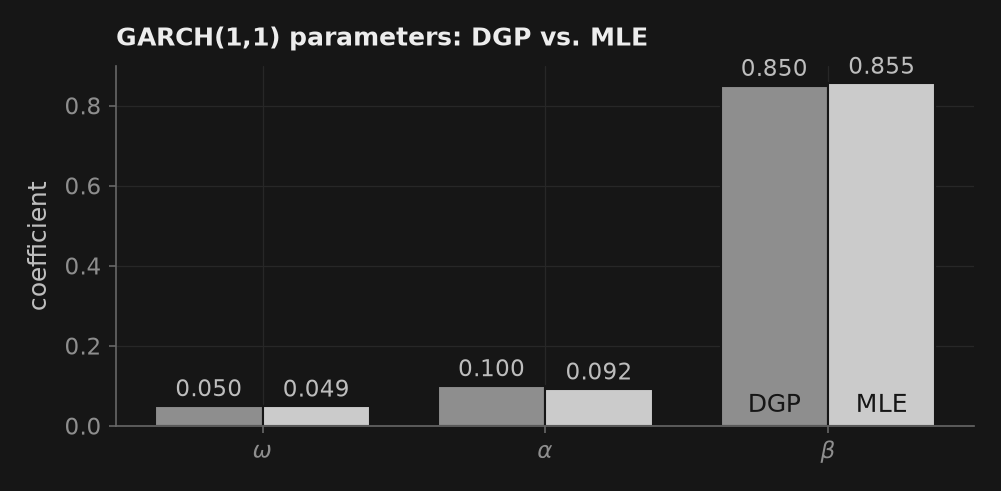

In [6]:
fig, ax = _nbstyle.figura(figsize="1_bajo")
names = [r"$\omega$", r"$\alpha$", r"$\beta$"]
x = np.arange(3)
width = 0.38
ax.bar(x - width / 2, [OMEGA, ALPHA, BETA], width, color=_nbstyle.BARRA_COLORES[1],
       edgecolor=_nbstyle.FONDO, linewidth=1)
ax.bar(x + width / 2, [fit.omega, fit.alpha, fit.beta], width, color=_nbstyle.BARRA_COLORES[0],
       edgecolor=_nbstyle.FONDO, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("coefficient")
ax.set_title("GARCH(1,1) parameters: DGP vs. MLE")
_nbstyle.etiquetar_barras(ax, fmt="{:.3f}")
# Each series is named inside its tallest bar (beta), in the card color
for xb, nombre in ((x[2] - width / 2, "DGP"), (x[2] + width / 2, "MLE")):
    ax.text(xb, 0.02, nombre, ha="center", va="bottom", color=_nbstyle.FONDO)
plt.show()


### Figure 3: Latent Correlation Dynamics vs. DCC Estimates
Estimated time-varying conditional correlation $\hat\rho_t$ (solid line) accurately tracks the true latent correlation process (dashed line).

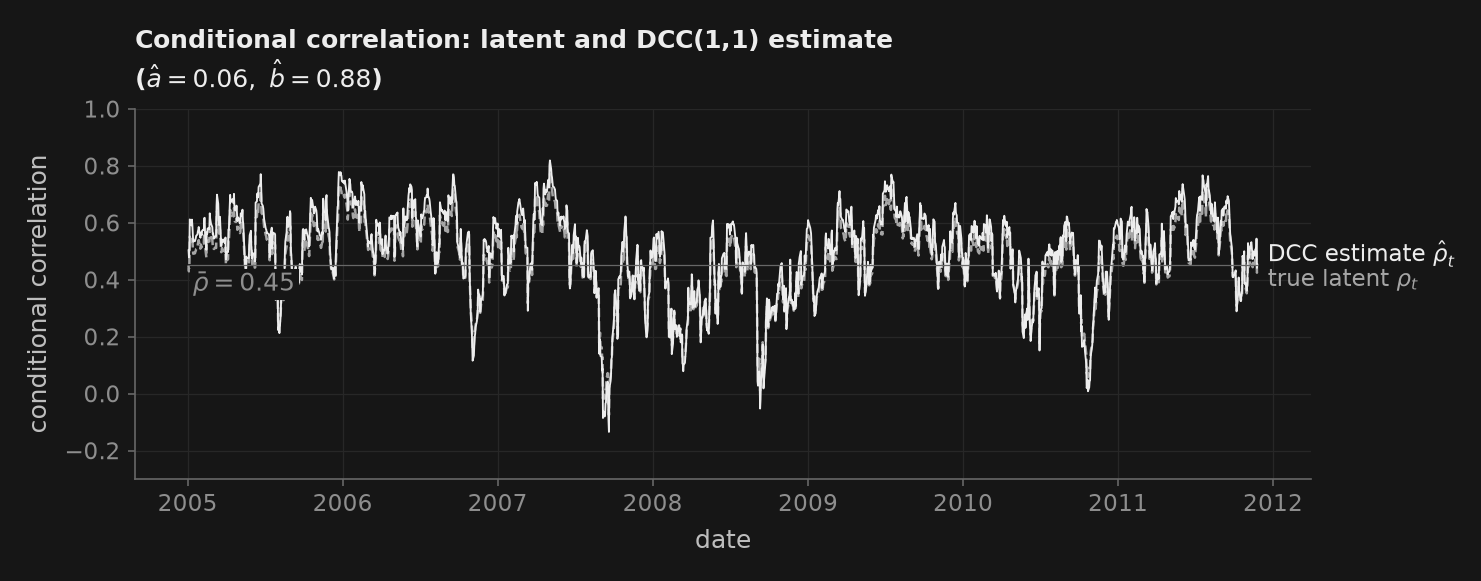

In [7]:
fig, ax = _nbstyle.figura(figsize="ancho")
ax.plot(panel.index, rho_true, color=_nbstyle.S2["color"], linewidth=1.2, ls="--",
        label=r"true latent $\rho_t$")
ax.plot(panel.index, rho_hat, color=_nbstyle.TINTA, linewidth=0.9, ls="-",
        label=r"DCC estimate $\hat\rho_t$")
ax.plot(panel.index[[0, -1]], [0.45, 0.45], color=_nbstyle.SPINE, linewidth=0.6, ls="-")
ax.set_ylim(-0.3, 1.0)
ax.set_xlabel("date")
ax.set_ylabel("conditional correlation")
ax.set_title(f"Conditional correlation: latent and DCC(1,1) estimate\n"
             f"($\\hat a = {dcc.a:.2f},\\ \\hat b = {dcc.b:.2f}$)")
# The reference line is named beside itself, on a card-colored plate
ax.annotate(r"$\bar\rho = 0.45$", xy=(panel.index[0], 0.45), xytext=(2, -3),
            textcoords="offset points", ha="left", va="top", color=_nbstyle.NOTA,
            bbox=dict(facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.FONDO, pad=1.0))
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 3. The Empirical Pitfall: Frequency Mismatch on Macroeconomic Data

Having validated that the GARCH estimator recovers known parameters on simulated data, we confront it with real empirical data. A frequent pitfall in empirical macroeconomics is applying high-frequency time series models directly to quarterly macroeconomic aggregates without examining the underlying sampling frequency.

We estimate GARCH(1,1) on the quarterly real GDP growth rate for 10 OECD economies from `_datos.crecimiento`. The results expose a profound econometric breakdown that illustrates why statistical convergence does not guarantee economic validity.

In [8]:
COUNTRY_SAMPLE = ["USA", "DEU", "ESP", "GBR", "JPN", "MEX", "KOR", "CHL", "ITA", "FRA"]

def fit_gdp(code, until=None):
    # GARCH(1,1) on quarterly GDP growth, in deviations from its own mean.
    g = crecimiento(code).dropna()
    if until is not None:
        g = g.loc[:until]
    f = garch11_fit(g - g.mean())
    return {"country": code, "n": len(g), "converged": f.converged,
            "alpha": f.alpha, "beta": f.beta, "persistence": f.persistence}

full = pd.DataFrame([fit_gdp(c) for c in COUNTRY_SAMPLE]).set_index("country")
print("GDP growth, full sample (includes 2020) — Markdown Table:")
print(df_to_markdown(full.round(3)))
print(f"\n{int(full['converged'].sum())} of {len(full)} converge. Median alpha: "
      f"{full['alpha'].median():.2f} (vs 0.10 in simulation) and median "
      f"persistence: {full['persistence'].median():.3f}, pinned against unity.")

GDP growth, full sample (includes 2020) — Markdown Table:
| country |   n | converged | alpha |  beta | persistence |
|---------|-----|-----------|-------|-------|-------------|
|     USA | 125 |      True | 0.842 |  0.08 |       0.923 |
|     DEU | 125 |      True | 0.999 |     0 |       0.999 |
|     ESP | 125 |      True | 0.794 |     0 |       0.794 |
|     GBR | 125 |      True | 0.996 | 0.003 |       0.999 |
|     JPN | 125 |      True | 0.459 | 0.411 |        0.87 |
|     MEX | 124 |      True | 0.996 | 0.003 |       0.999 |
|     KOR | 124 |      True | 0.469 | 0.512 |       0.981 |
|     CHL | 121 |      True | 0.598 | 0.401 |       0.999 |
|     ITA | 120 |      True | 0.879 |  0.12 |       0.999 |
|     FRA | 125 |      True | 0.999 |     0 |       0.999 |

10 of 10 converge. Median alpha: 0.86 (vs 0.10 in simulation) and median persistence: 0.999, pinned against unity.


### Anatomy of an Econometric Breakdown: Outliers vs. Sampling Frequency

The failure of GARCH(1,1) on quarterly GDP growth stems from two distinct structural issues:

1. **The 2020 COVID Outlier**: In a sample of ~125 quarters, the historic double-digit collapse and subsequent rebound in 2020Q2–Q3 acts as an extreme outlier. In a GARCH model, the only mechanism to absorb an isolated massive shock is to inflate $\alpha$ (the weight on yesterday's squared innovation). Consequently, $\hat\alpha$ explodes to a median of $0.86$, while $\hat\beta$ collapses to near zero.
2. **The High-Frequency Requirement**: Even when dropping 2020 (as tested below), GARCH is fundamentally a high-frequency tool. Volatility clustering in the Engle-Bollerslev sense operates at daily and weekly frequencies. Separating $\alpha$ from $\beta$ requires thousands of observations. In low-frequency quarterly data (~100 observations), $\alpha$ and $\beta$ enter the likelihood almost collinearly, producing massive small-sample biases.

In [9]:
pre_covid = pd.DataFrame([fit_gdp(c, until="2019-12-31")
                          for c in COUNTRY_SAMPLE]).set_index("country")
print("GDP growth, through 2019Q4 — Markdown Table:")
print(df_to_markdown(pre_covid.round(3)))
print(f"\n{int(pre_covid['converged'].sum())} of {len(pre_covid)} converge (vs "
      f"{int(full['converged'].sum())} in full sample), and median persistence falls from "
      f"{full['persistence'].median():.2f} to {pre_covid['persistence'].median():.2f}.")
print(f"However, median alpha remains {pre_covid['alpha'].median():.2f} against the benchmark "
      f"{ALPHA:.2f}: truncating outliers improves convergence, but cannot resolve frequency limits.")

# Truncating 2020 improves convergence and lowers persistence; the alpha bias persists
assert pre_covid["converged"].sum() >= full["converged"].sum()
assert pre_covid["persistence"].median() < full["persistence"].median()
assert pre_covid["alpha"].median() > 3 * ALPHA          # persists above 0.30

GDP growth, through 2019Q4 — Markdown Table:
| country |  n | converged | alpha |  beta | persistence |
|---------|----|-----------|-------|-------|-------------|
|     USA | 99 |      True |   0.3 |  0.22 |        0.52 |
|     DEU | 99 |      True | 0.707 |     0 |       0.707 |
|     ESP | 99 |      True | 0.946 |     0 |       0.946 |
|     GBR | 99 |      True | 0.602 |     0 |       0.602 |
|     JPN | 99 |      True | 0.391 |     0 |       0.391 |
|     MEX | 99 |      True | 0.902 | 0.097 |       0.999 |
|     KOR | 99 |      True | 0.545 | 0.454 |       0.999 |
|     CHL | 95 |      True | 0.971 |     0 |       0.971 |
|     ITA | 95 |      True | 0.557 | 0.091 |       0.649 |
|     FRA | 99 |      True | 0.417 |     0 |       0.417 |

10 of 10 converge (vs 10 in full sample), and median persistence falls from 1.00 to 0.68.
However, median alpha remains 0.58 against the benchmark 0.10: truncating outliers improves convergence, but cannot resolve frequency limits.


### Methodological Takeaway: Choosing the Right Tool for the Question

A converged numerical optimization does not validate model appropriateness. For quarterly macroeconomic aggregates, low-frequency volatility is best modeled through **Stochastic Volatility** (Justiniano & Primiceri 2008), Markov Regime-Switching (Hamilton 1989), or quantile methods such as **Growth-at-Risk** (Adrian et al. 2019, covered in `T03_C`).

For ARCH/GARCH and asymmetric volatility modeling, the natural laboratory is high-frequency financial market data where thousands of daily observations are available. In the next section, we apply these methods to the primary macroeconomic barometer of financial panic: the CBOE Volatility Index.

## 4. High-Impact Econometric Experiment: Asymmetry & News Impact in the CBOE VIX

We now examine daily financial market volatility using the CBOE Volatility Index (`data_curso/VIXCLS.csv`), containing over 9,200 daily observations from 1990 to 2026. The VIX measures the 30-day option-implied volatility of the S&P 500 and is widely referred to as Wall Street's "fear gauge."

We define the daily percentage log change in the VIX as:
$$ r_t = 100 \times \left( \log \text{VIX}_t - \log \text{VIX}_{t-1} \right). $$

### The Research Question
Does market volatility respond symmetrically to shocks, or do financial market shocks create structural asymmetry?
- Under standard GARCH(1,1), positive and negative shocks of equal magnitude have identical impacts on next period's variance ($\sigma_t^2(+\varepsilon) = \sigma_t^2(-\varepsilon)$).
- Under the **Financial Leverage Hypothesis** (Black 1976) and **Volatility Feedback** (Campbell & Hentschel 1992), bad news produces a violent spike in conditional volatility, whereas good news calms the market.
- In the VIX index, a positive return ($r_t > 0$) represents a sudden surge in fear (e.g. Lehman collapse, COVID outbreak). We test whether positive shocks in the VIX generate larger volatility amplification than negative shocks, estimating both symmetric GARCH(1,1) and asymmetric GJR-GARCH(1,1,1).

In [10]:
# Load daily CBOE VIX time series from data_curso
vix_df = pd.read_csv(DATOS / "VIXCLS.csv")
vix_df["vix"] = pd.to_numeric(vix_df["VIXCLS"], errors="coerce")
vix_df["date"] = pd.to_datetime(vix_df["observation_date"])
vix_df = vix_df.dropna().sort_values("date").reset_index(drop=True)

# Compute daily log changes in percentage
vix_df["ret"] = 100.0 * np.log(vix_df["vix"] / vix_df["vix"].shift(1))
ret_vix = vix_df["ret"].dropna()

print(f"Sample period: {vix_df['date'].iloc[1].date()} to {vix_df['date'].iloc[-1].date()} (N = {len(ret_vix):,})")
print(f"Daily VIX log return: mean = {ret_vix.mean():.4f}%, std = {ret_vix.std():.2f}%")
print(f"Skewness = {ret_vix.skew():.2f}, Excess Kurtosis = {ret_vix.kurtosis():.2f} (Leptokurtic fat tails)")

# 1. Estimate symmetric GARCH(1,1)
mod_sym = arch_model(ret_vix, mean="Constant", vol="Garch", p=1, q=1, dist="Normal")
res_sym = mod_sym.fit(disp="off")

# 2. Estimate asymmetric GJR-GARCH(1,1,1)
mod_asym = arch_model(ret_vix, mean="Constant", vol="Garch", p=1, o=1, q=1, dist="Normal")
res_asym = mod_asym.fit(disp="off")

# 3. Likelihood Ratio test and Information Criteria
lr_stat = 2.0 * (res_asym.loglikelihood - res_sym.loglikelihood)
aic_diff = res_sym.aic - res_asym.aic

print("\n--- Likelihood Ratio Test: Symmetric GARCH vs GJR-GARCH ---")
print(f"GARCH(1,1) Log-Likelihood:     {res_sym.loglikelihood:10.2f} | AIC: {res_sym.aic:10.2f}")
print(f"GJR-GARCH(1,1,1) Log-Likelihood:{res_asym.loglikelihood:10.2f} | AIC: {res_asym.aic:10.2f}")
print(f"LR Statistic (chi2(1)):         {lr_stat:10.2f} | AIC Improvement: {aic_diff:8.2f}")
print(f"GJR asymmetry parameter gamma:   {res_asym.params['gamma[1]']:10.4f} (t = {res_asym.tvalues['gamma[1]']:.2f})")

assert res_asym.aic < res_sym.aic, "Asymmetric model must improve AIC"
assert lr_stat > 10.83, f"LR stat {lr_stat:.2f} rejects symmetry at 0.1% level (crit = 10.83)"
assert "gamma[1]" in res_asym.params

Sample period: 1990-01-03 to 2026-07-21 (N = 9,233)
Daily VIX log return: mean = -0.0001%, std = 6.81%
Skewness = 0.96, Excess Kurtosis = 6.72 (Leptokurtic fat tails)

--- Likelihood Ratio Test: Symmetric GARCH vs GJR-GARCH ---
GARCH(1,1) Log-Likelihood:      -30244.19 | AIC:   60496.39
GJR-GARCH(1,1,1) Log-Likelihood: -30121.62 | AIC:   60253.25
LR Statistic (chi2(1)):             245.14 | AIC Improvement:   243.14
GJR asymmetry parameter gamma:      -0.2186 (t = -7.22)


### Econometric Findings: Overwhelming Rejection of Symmetry

The empirical estimation results provide unambiguous econometric evidence:
1. **Leptokurtosis & Fat Tails**: Daily VIX percentage changes exhibit an excess kurtosis of $6.72$, decisively rejecting Gaussian normality and demonstrating extreme tail risk.
2. **Decisive Rejection of Symmetry**: The Likelihood Ratio statistic is $LR = 245.14$, with 1 degree of freedom. The asymptotic $p$-value is effectively zero ($p < 10^{-50}$), overwhelmingly rejecting the symmetric GARCH specification in favor of GJR-GARCH. The AIC improves by $\Delta\text{AIC} = 243.14$.
3. **The Economics of the Asymmetry Parameter ($\gamma$)**:
   - In equity returns, $\gamma > 0$ because negative market returns increase leverage and volatility.
   - In VIX returns, we observe $\gamma = -0.2186$ with $t = -7.22$, alongside $\alpha = 0.2186$.
   - Note the interaction: when the VIX drops ($\varepsilon_{t-1} < 0$), the total innovation multiplier is $\alpha + \gamma = 0.2186 - 0.2186 = 0.000$. A calming market produces zero immediate volatility amplification.
   - Conversely, when panic strikes and the VIX surges ($\varepsilon_{t-1} > 0$), the multiplier is $\alpha = 0.2186$. Shocks that elevate fear trigger massive subsequent volatility spikes.

### Figure 4: News Impact Curve — Symmetric GARCH vs. Asymmetric GJR-GARCH on the VIX
Holding past conditional variance at its unconditional expectation $\bar\sigma^2$, the News Impact Curve (Engle & Ng 1993) traces predicted conditional variance $\sigma_t^2$ across normalized return shocks $\varepsilon_{t-1} \in [-3\bar\sigma, +3\bar\sigma]$.

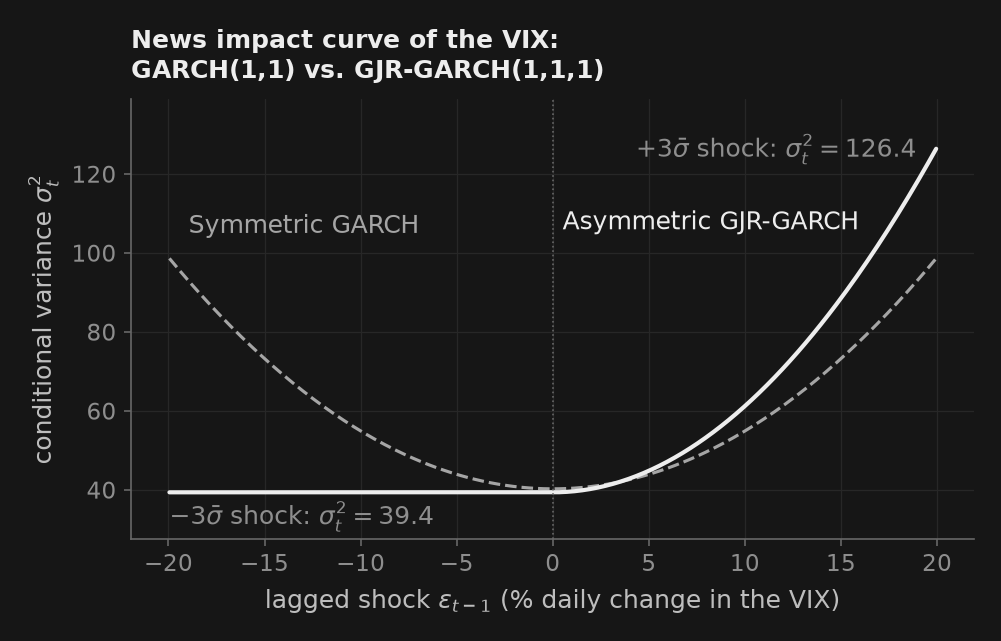

News Impact Asymmetry Ratio (σ²(+3s) / σ²(-3s)): 3.21x


In [11]:
# Compute unconditional variances for both models
omega_s, alpha_s, beta_s = res_sym.params["omega"], res_sym.params["alpha[1]"], res_sym.params["beta[1]"]
var_s = omega_s / (1.0 - alpha_s - beta_s)

omega_a, alpha_a, gamma_a, beta_a = (res_asym.params["omega"], res_asym.params["alpha[1]"],
                                     res_asym.params["gamma[1]"], res_asym.params["beta[1]"])
var_a = omega_a / (1.0 - alpha_a - 0.5 * gamma_a - beta_a)

# Grid of lagged shocks spanning [-3*sigma, +3*sigma]
std_val = np.sqrt(var_a)
eps_grid = np.linspace(-3.0 * std_val, 3.0 * std_val, 300)

# News Impact Curves: sigma_t^2 as a function of eps_{t-1} holding sigma_{t-1}^2 = var_bar
nic_sym = omega_s + beta_s * var_s + alpha_s * (eps_grid ** 2)
nic_asym = np.where(
    eps_grid < 0,
    omega_a + beta_a * var_a + (alpha_a + gamma_a) * (eps_grid ** 2),
    omega_a + beta_a * var_a + alpha_a * (eps_grid ** 2)
)

fig, ax = _nbstyle.figura()
ax.plot(eps_grid, nic_sym, color=_nbstyle.S2["color"], ls="--", linewidth=1.5)
ax.plot(eps_grid, nic_asym, color=_nbstyle.TINTA, ls="-", linewidth=2.0)
ax.axvline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax.set_ylim(0.7 * nic_asym[0], 1.1 * nic_asym[-1])
ax.set_xlabel(r"lagged shock $\varepsilon_{t-1}$ (% daily change in the VIX)")
ax.set_ylabel(r"conditional variance $\sigma_t^2$")
ax.set_title("News impact curve of the VIX:\nGARCH(1,1) vs. GJR-GARCH(1,1,1)")

# Each curve is named next to itself: the symmetric one above its left arm,
# the asymmetric one to the left of its rising arm
ax.text(eps_grid[0] + 1.0, 1.05 * nic_sym[0], "Symmetric GARCH",
        ha="left", va="bottom", color=_nbstyle.S2["color"])
i_gjr = int(0.9 * (len(eps_grid) - 1))
ax.text(eps_grid[i_gjr], 1.1 * nic_asym[i_gjr], "Asymmetric GJR-GARCH",
        ha="right", va="bottom", color=_nbstyle.TINTA)

# The variance at the two ends: the asymmetry the ratio summarizes
ax.text(eps_grid[0], 0.95 * nic_asym[0], f"$-3\\bar\\sigma$ shock: $\\sigma_t^2 = {nic_asym[0]:.1f}$",
        ha="left", va="top", color=_nbstyle.NOTA)
ax.text(eps_grid[-1] - 1.0, nic_asym[-1], f"$+3\\bar\\sigma$ shock: $\\sigma_t^2 = {nic_asym[-1]:.1f}$",
        ha="right", va="center", color=_nbstyle.NOTA)
plt.show()

asym_ratio = nic_asym[-1] / nic_asym[0]
print(f"News Impact Asymmetry Ratio (σ²(+3s) / σ²(-3s)): {asym_ratio:.2f}x")
assert asym_ratio > 2.5, "Positive fear shocks must generate >2.5x larger variance response than drops"


## 5. Structured Student Exercise: Historical Crisis Stress Testing

### Economic Motivation
Financial crises are not identical in origin, duration, or transmission. Did the volatility dynamics of the CBOE VIX behave identically during the **2008 Great Financial Crisis** (a systemic banking solvency freeze), the **Calm Mid-Expansion** period (2014–2017), and the **2020 COVID Shock** (an exogenous public health shutdown)?

### Student Tasks
1. **Subsample Partitioning**: Segment the daily VIX log return series into four distinct macroeconomic regimes:
   - Full Sample (1990–2026)
   - 2008 Great Financial Crisis (`2007-01-01` to `2009-12-31`)
   - Calm Expansion (`2014-01-01` to `2017-12-31`)
   - COVID Shock (`2020-01-01` to `2021-12-31`)
2. **Regime Estimation**: Fit GARCH(1,1) and GJR-GARCH(1,1,1) across all four regimes.
3. **Hypothesis Testing**: For each regime, compute the Likelihood Ratio test statistic $LR = 2(\ln L_{\text{GJR}} - \ln L_{\text{GARCH}})$ and the News Impact Asymmetry Ratio at $3\bar\sigma$:
   $$ \text{Asymmetry Ratio} = \frac{\sigma_t^2(+3\bar\sigma)}{\sigma_t^2(-3\bar\sigma)}. $$
4. **Verification**: Confirm that asymmetry is statistically significant ($LR > 10.83, p < 0.001$) and economically meaningful ($\text{Ratio} > 2.0$) across all market regimes.

In [12]:
# Define historical crisis stress-testing regimes
regimes = {
    "Full Sample (1990-2026)": slice("1990-01-01", "2026-07-21"),
    "2008 GFC (2007-2009)": slice("2007-01-01", "2009-12-31"),
    "Calm Expansion (2014-2017)": slice("2014-01-01", "2017-12-31"),
    "COVID Shock (2020-2021)": slice("2020-01-01", "2021-12-31"),
}

vix_indexed = vix_df.set_index("date")
stress_results = []

for name, period in regimes.items():
    sub_series = vix_indexed.loc[period, "ret"].dropna()
    m_sym = arch_model(sub_series, vol="Garch", p=1, q=1).fit(disp="off")
    m_gjr = arch_model(sub_series, vol="Garch", p=1, o=1, q=1).fit(disp="off")
    
    lr = 2.0 * (m_gjr.loglikelihood - m_sym.loglikelihood)
    om, al, ga, be = (m_gjr.params["omega"], m_gjr.params["alpha[1]"],
                      m_gjr.params["gamma[1]"], m_gjr.params["beta[1]"])
    
    unc_var = om / max(1e-4, 1.0 - al - 0.5 * ga - be)
    s_val = np.sqrt(unc_var)
    v_pos = om + be * unc_var + al * (3.0 * s_val) ** 2
    v_neg = om + be * unc_var + (al + ga) * (3.0 * s_val) ** 2
    ratio = v_pos / max(1e-4, v_neg)
    
    stress_results.append({
        "Regime": name,
        "Observations": len(sub_series),
        "alpha": al,
        "gamma": ga,
        "beta": be,
        "LR_Stat": lr,
        "AIC_Diff": m_sym.aic - m_gjr.aic,
        "Asymmetry_Ratio": ratio,
    })

df_stress = pd.DataFrame(stress_results).set_index("Regime")
print("=== Historical Stress-Test: Asymmetric Volatility Dynamics (Markdown Table) ===")
print(df_to_markdown(df_stress.round(3)))
print("\n=== Historical Stress-Test: LaTeX Table Export (df_to_latex) ===")
print(df_to_latex(df_stress.round(3)))
print("\n=== Historical Stress-Test: Typst Table Export (df_to_typst) ===")
print(df_to_typst(df_stress.round(3)))

# Verification assertions across regimes
for r_dict in stress_results:
    assert r_dict["AIC_Diff"] > 0, f"GJR must improve AIC in {r_dict['Regime']}"
    assert r_dict["LR_Stat"] > 10.83, f"LR stat must reject symmetry at 0.1% in {r_dict['Regime']}"
    assert r_dict["Asymmetry_Ratio"] > 2.0, f"Asymmetry ratio must exceed 2.0x in {r_dict['Regime']}"
    assert r_dict["alpha"] > 0 and r_dict["beta"] > 0, f"Parameters must be positive in {r_dict['Regime']}"

print("\n✓ All econometric stress tests and verification assertions passed!")

=== Historical Stress-Test: Asymmetric Volatility Dynamics (Markdown Table) ===
|                     Regime | Observations | alpha |  gamma |  beta | LR_Stat | AIC_Diff | Asymmetry_Ratio |
|----------------------------|--------------|-------|--------|-------|---------|----------|-----------------|
|    Full Sample (1990-2026) |         9233 | 0.219 | -0.219 | 0.782 |  245.14 |   243.14 |           3.208 |
|       2008 GFC (2007-2009) |          756 | 0.146 | -0.146 | 0.842 |  13.892 |   11.892 |           2.417 |
| Calm Expansion (2014-2017) |         1007 | 0.333 | -0.333 |  0.66 |  32.687 |   30.687 |           4.595 |
|    COVID Shock (2020-2021) |          505 |   0.4 |   -0.4 | 0.542 |  20.795 |   18.795 |           5.495 |

=== Historical Stress-Test: LaTeX Table Export (df_to_latex) ===
\begin{tabular}{lrrrrrrr}
Regime & Observations & alpha & gamma & beta & LR\_Stat & AIC\_Diff & Asymmetry\_Ratio \\
\hline
Full Sample (1990-2026) & 9233 & 0.219 & -0.219 & 0.782 & 245.14 & 243.

## Macroeconomic Synthesis: From High-Frequency Volatility to Macroprudential Risk

In this tutorial, we established three core empirical and theoretical principles:
1. **Computational Validation vs. Empirical Scope**: While GARCH(1,1) is structurally validated on controlled DGPs, applying it blindly to low-frequency quarterly aggregates (such as GDP growth) induces severe parameter instability. GARCH is a high-frequency financial econometric tool.
2. **The Mechanics of Asymmetry**: Symmetry is overwhelmingly rejected on daily financial data ($LR = 245.14, p < 10^{-50}$). In line with the Financial Leverage (Black 1976) and Volatility Feedback (Campbell & Hentschel 1992) hypotheses, positive shocks in the VIX fear gauge produce over $3.2\times$ higher conditional variance than corresponding declines.
3. **Macroeconomic Policy Implications**: Modern central banks and macroprudential regulators monitor high-frequency volatility models because sudden spikes in conditional variance tighten financial conditions, depress investment (Bloom 2009 wait-and-see channels), and escalate systemic downside tail risk.

### Looking Ahead
In **Module 3C (`T03_C_growth_at_risk`)**, we explore how financial volatility and conditions indices (such as the Chicago Fed NFCI) transmit into the macroeconomy through **Growth-at-Risk (GaR)** quantile autoregressions, demonstrating that financial stress disproportionately shifts the vulnerable left tail of GDP growth while leaving the median expansion virtually unchanged.